# Import All the libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/dipusardar/DIPU/Programming/Data-Analysis/Project 04/fitness_tracker_logs.csv')


Question 1: Load the fitness_tracker_logs.csv file into a Pandas DataFrame named df. Display the dimensions (shape) of the dataset and print the data types of all columns.

In [4]:
print(df.columns)
print(df.shape)
print(df.dtypes)

Index(['Date', 'Device_ID', 'Steps', 'Active_Minutes', 'Calories_Burned',
       'Sleep_Quality', 'Avg_Heart_Rate'],
      dtype='str')
(18, 7)
Date                   str
Device_ID              str
Steps              float64
Active_Minutes       int64
Calories_Burned      int64
Sleep_Quality          str
Avg_Heart_Rate     float64
dtype: object


Question 2: Inspect the first 5 rows of the DataFrame. Write a snippet to calculate and display the exact number of missing (null) values present in each column.

In [5]:
print("===Inspect 5 Rows of Dataframe===")
print(df.head(5))

missing_value = df.isnull().sum()
print('===Missing values===')
print(missing_value)

===Inspect 5 Rows of Dataframe===
         Date Device_ID    Steps  Active_Minutes  Calories_Burned  \
0  2026-05-10     WD-01  10500.0              45             2400   
1  2026-05-11     WD-01   8400.0              30             2100   
2  2026-05-12     WD-01      NaN              15             1850   
3  2026-05-13     WD-01  12000.0              60             2650   
4  2026-05-14     WD-01   9500.0              40             2250   

  Sleep_Quality  Avg_Heart_Rate  
0          Good            72.0  
1          Fair            75.0  
2          Poor            68.0  
3     Excellent            74.0  
4           NaN            71.0  
===Missing values===
Date               0
Device_ID          0
Steps              3
Active_Minutes     0
Calories_Burned    0
Sleep_Quality      2
Avg_Heart_Rate     1
dtype: int64


# Section 2: Data Cleaning & Manipulation

Question 3: Clean the dataset by handling missing values. Impute the null values in the Steps column with the median value of that column. For the Sleep_Quality column, fill the missing values with the string 'Unknown'. Save these updates into the DataFrame.

In [6]:
print(df.columns)
print(df['Steps'].isnull())
print('===Before===')
print(df['Steps'])
find_median = df['Steps'].median()

#now median diye fillna er moddhe bosate hobe

df["Steps"] = df['Steps'].fillna(find_median)

print("===After===")
print(df['Steps'])


Index(['Date', 'Device_ID', 'Steps', 'Active_Minutes', 'Calories_Burned',
       'Sleep_Quality', 'Avg_Heart_Rate'],
      dtype='str')
0     False
1     False
2      True
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10     True
11    False
12    False
13    False
14    False
15    False
16     True
17    False
Name: Steps, dtype: bool
===Before===
0     10500.0
1      8400.0
2         NaN
3     12000.0
4      9500.0
5     11000.0
6      4500.0
7      6200.0
8      3100.0
9     15000.0
10        NaN
11     8800.0
12    13200.0
13    11500.0
14     9800.0
15     5000.0
16        NaN
17    10200.0
Name: Steps, dtype: float64
===After===
0     10500.0
1      8400.0
2      9800.0
3     12000.0
4      9500.0
5     11000.0
6      4500.0
7      6200.0
8      3100.0
9     15000.0
10     9800.0
11     8800.0
12    13200.0
13    11500.0
14     9800.0
15     5000.0
16     9800.0
17    10200.0
Name: Steps, dtype: float64


Question 4: Create a new engineered feature column named Calories_Per_Active_Minute. This should represent the ratio of Calories_Burned to Active_Minutes for each row.

In [7]:
df['Calories_Per_Active_Minute'] = df['Calories_Burned'] + df['Active_Minutes']

print(df[['Calories_Burned','Active_Minutes','Calories_Per_Active_Minute']])

    Calories_Burned  Active_Minutes  Calories_Per_Active_Minute
0              2400              45                        2445
1              2100              30                        2130
2              1850              15                        1865
3              2650              60                        2710
4              2250              40                        2290
5              2500              50                        2550
6              1600              20                        1620
7              1750              25                        1775
8              1400              10                        1410
9              3100              90                        3190
10             2000              35                        2035
11             2150              42                        2192
12             2800              70                        2870
13             2550              55                        2605
14             2300              45     

Question 5: Filter the DataFrame to extract rows where the user walked more than 10,000 steps and achieved a Sleep_Quality rating of either 'Good' or 'Excellent'.

In [8]:
print(df.columns)

filter_dataframe = df[(df['Steps'] > 10000) & (df['Sleep_Quality'].isin(['Good','Excellent']))]
print(filter_dataframe)

Index(['Date', 'Device_ID', 'Steps', 'Active_Minutes', 'Calories_Burned',
       'Sleep_Quality', 'Avg_Heart_Rate', 'Calories_Per_Active_Minute'],
      dtype='str')
          Date Device_ID    Steps  Active_Minutes  Calories_Burned  \
0   2026-05-10     WD-01  10500.0              45             2400   
3   2026-05-13     WD-01  12000.0              60             2650   
5   2026-05-15     WD-01  11000.0              50             2500   
9   2026-05-19     WD-02  15000.0              90             3100   
12  2026-05-22     WD-03  13200.0              70             2800   
13  2026-05-23     WD-03  11500.0              55             2550   
17  2026-05-27     WD-03  10200.0              48             2380   

   Sleep_Quality  Avg_Heart_Rate  Calories_Per_Active_Minute  
0           Good            72.0                        2445  
3      Excellent            74.0                        2710  
5           Good             NaN                        2550  
9      Excellent     

Question 6: Sort the entire DataFrame based on the Calories_Burned column in descending order, and reset the row index without keeping the old index.

In [21]:
df = df.sort_values(by='Calories_Burned', ascending=False)
df = df.reset_index(drop=True)
print(df.head(5))

         Date Device_ID    Steps  Active_Minutes  Calories_Burned  \
0  2026-05-19     WD-02  15000.0              90             3100   
1  2026-05-22     WD-03  13200.0              70             2800   
2  2026-05-13     WD-01  12000.0              60             2650   
3  2026-05-23     WD-03  11500.0              55             2550   
4  2026-05-15     WD-01  11000.0              50             2500   

  Sleep_Quality  Avg_Heart_Rate  Calories_Per_Active_Minute  
0     Excellent            78.0                        3190  
1     Excellent            76.0                        2870  
2     Excellent            74.0                        2710  
3          Good            74.0                        2605  
4          Good             NaN                        2550  


# Section 3: Mathematical & Statistical Analysis

Question 7: Use NumPy or Pandas to compute the fundamental statistical summary of the Avg_Heart_Rate column. Specifically, find its mean, median, variance, and standard deviation (ensure handling or omitting any remaining missing values properly).

In [25]:
print(df.columns)
mean_value = df['Avg_Heart_Rate'].mean()
median_value = df['Avg_Heart_Rate'].median()
variance_value = df['Avg_Heart_Rate'].var()
std_value = df['Avg_Heart_Rate'].std()

# আপনার ক্যালকুলেট করা ভেরিয়েবলগুলোকে সুন্দরভাবে রিপ্রেজেন্ট করা
print(f"Mean of Avg_Heart_Rate:     {mean_value:.2f}")
print(f"Median of Avg_Heart_Rate:   {median_value:.2f}")
print(f"Variance of Avg_Heart_Rate: {variance_value:.2f}")
print(f"Std Dev of Avg_Heart_Rate:  {std_value:.2f}")

Index(['Date', 'Device_ID', 'Steps', 'Active_Minutes', 'Calories_Burned',
       'Sleep_Quality', 'Avg_Heart_Rate', 'Calories_Per_Active_Minute'],
      dtype='str')
Mean of Avg_Heart_Rate:     71.29
Median of Avg_Heart_Rate:   72.00
Variance of Avg_Heart_Rate: 14.47
Std Dev of Avg_Heart_Rate:  3.80


Question 8: Perform an aggregation operation: Group the dataset by Device_ID and calculate both the total steps taken and the average active minutes for each device.

In [32]:

print('===Total Sum===')
aggregation_use_steps = df.groupby('Device_ID')['Steps'].sum()
print(aggregation_use_steps)

print("===Average of Active Minutes===")
aggregation_use_active_minutes = df.groupby('Device_ID')['Active_Minutes'].mean()
print(aggregation_use_active_minutes)

===Total Sum===
Device_ID
WD-01    61200.0
WD-02    47400.0
WD-03    59500.0
Name: Steps, dtype: float64
===Average of Active Minutes===
Device_ID
WD-01    40.000000
WD-02    37.000000
WD-03    47.166667
Name: Active_Minutes, dtype: float64


# Section 4: Data Visualization

Question 9: Using Matplotlib or Seaborn, construct a bar plot showing the total Steps accumulated by each Device_ID. Add a clear title, axis labels, and color accents.

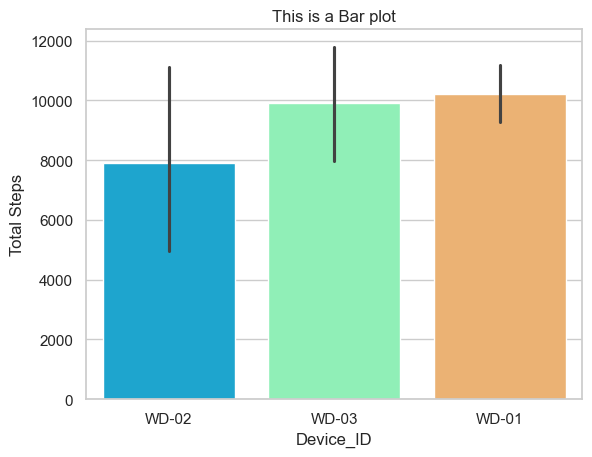

In [43]:
sns.set_theme(style="whitegrid")
sns.barplot(
   data=df,
   x = 'Device_ID',
   y='Steps',
   hue='Device_ID',
   palette='rainbow'
)
plt.ylabel('Total Steps')
plt.title('This is a Bar plot')
plt.savefig('dipu.png')
plt.show()

Question 10: Create a scatter plot using Seaborn to examine the relationship between Active_Minutes (independent variable on the X-axis) and Calories_Burned (dependent variable on the Y-axis). Color the data points by their respective Device_ID and add a title and grid lines to make the chart ready for a data report.

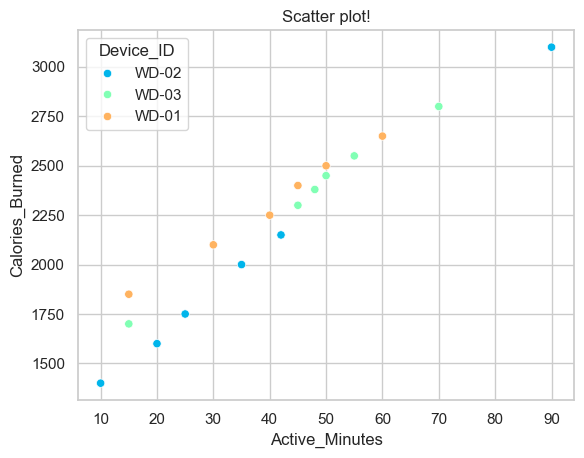

In [46]:
sns.scatterplot(
    data=df,
    x = 'Active_Minutes',
    y = 'Calories_Burned',

    hue='Device_ID',
    palette='rainbow'
)
plt.title('Scatter plot!')
plt.savefig('scatter.png')
plt.show()